# End_to_End_Telecom_Case Study

Part1 :Telecom Customer Segmentation (RFM + K-Means)
Telecom (`Customer.csv` + `Payments.csv`).

**RFM :**
- **Recency:** No.Days since snapshot date
- **Frequency:** No.Payment_iD
- **Monetary:** The Profit

In [ ]:
import pandas as pd
import numpy as np

# --- Load the datasets ---
customers_df = pd.read_csv('Customer.csv')
payments_df = pd.read_csv('Payments.csv')

print("Customers DataFrame:", customers_df.shape)
print(customers_df.head())

print("\nPayments DataFrame:", payments_df.shape)
print(payments_df.head())

Customers DataFrame: (9995, 17)
   SUBSCRIBER_ID#         ACCOUNT_ID#      CUSTOMER_ID#     GROUP_ID#  \
0      2207712503  111452230007712503        1107671773           NaN   
1      2206313482  111130000088337202        1106271161           NaN   
2       132691373  107670000117446618  1011011004137519           NaN   
3        56271964  116480000024409877  1011011013308161           NaN   
4        54677049  114510000121790328        1107079372  2.019910e+16   

            NAME SUBSCRIBER_STATUS STATUS_DATE  GENDER   BIRTHDATE  ID_TYPE  \
0   ليلى العتيبي            Active  2019-01-17  female  1994-08-04  ID Card   
1   شهد القحطاني            Active  2018-01-09  female  1990-01-10  ID Card   
2   ليلى العراقي            Active  2025-02-09  female  1993-04-21  ID Card   
3  أحمد القحطاني            Active  2020-06-26    male  1999-10-03  ID Card   
4   خالد السبيعي            Active  2025-01-15    male  1989-05-12  ID Card   

  NATIONALITY          ACTIVATION_DATE CUSTOMER_CLASS 

## Step 1: Data Quality Checks
before Join

In [ ]:
# --- Duplicates & keys ---
print("Duplicated SUBSCRIBER_ID# :", customers_df['SUBSCRIBER_ID#'].duplicated().sum())
print("Duplicated CUSTOMER_ID#   :", customers_df['CUSTOMER_ID#'].duplicated().sum(),)
print("Duplicated Payment_ID     :", payments_df['Payment_ID'].duplicated().sum())

# --- Join coverage
print("\nPayments rows matched to a subscriber:",
      payments_df['SUBSCRIBER_ID'].isin(customers_df['SUBSCRIBER_ID#']).mean())

# --- Dates ---
payments_df['CONNECT_DATE'] = pd.to_datetime(payments_df['CONNECT_DATE'])
print("\nPayments date range:", payments_df['CONNECT_DATE'].min(), "->", payments_df['CONNECT_DATE'].max())

# --- Nulls ---
print("\nNulls in Payments:", payments_df.isna().sum().sum())

Duplicated SUBSCRIBER_ID# : 0
Duplicated CUSTOMER_ID#   : 2
Duplicated Payment_ID     : 0

Payments rows matched to a subscriber: 1.0

Payments date range: 2023-01-01 00:00:00 -> 2025-05-20 00:00:00

Nulls in Payments: 0


## Step 2: Payments Understanding


In [ ]:
# RENT = IN_BUNDLE + ADDON ?
is_sum = (payments_df['RENT_REVENUE'] - (payments_df['IN_BUNDLE_REVENUE'] + payments_df['ADDON_REVENUE'])).abs() < 0.01
print(f"RENT_REVENUE == IN_BUNDLE + ADDON {is_sum.mean():.4%} ")
print("OUT_BUNDLE_REVENUE total:", payments_df['OUT_BUNDLE_REVENUE'].sum())
print("TAX_AMOUNT total        :", payments_df['TAX_AMOUNT'].sum())

RENT_REVENUE == IN_BUNDLE + ADDON 100.0000% 
OUT_BUNDLE_REVENUE total: 0
TAX_AMOUNT total        : 0


**Result:** `RENT_REVENUE` = `IN_BUNDLE` + `ADDON`

**Monetary = RENT + OUT_BUNDLE + DEVICES + CREATION_FEES** (Tax is Zero)

In [ ]:
payments_df['Total_Revenue'] = (payments_df['RENT_REVENUE']
                              + payments_df['OUT_BUNDLE_REVENUE']
                              + payments_df['DEVICES_REVENUE']
                              + payments_df['CREATION_FEES_REVENUE'])
print(payments_df['Total_Revenue'].describe())

count    362713.000000
mean        150.119684
std         146.965589
min           5.000000
25%          50.000000
50%         160.000000
75%         210.000000
max       17610.000000
Name: Total_Revenue, dtype: float64


## Step 3: Merge Customers with Payments


In [ ]:
# SUBSCRIBER_ID# is Unique ?
customers_unique = customers_df.drop_duplicates(subset='SUBSCRIBER_ID#')

rfm_merged_df = pd.merge(payments_df,
                         customers_unique[['SUBSCRIBER_ID#', 'CUSTOMER_ID#', 'SUBSCRIBER_STATUS', 'CUSTOMER_CLASS']],
                         left_on='SUBSCRIBER_ID', right_on='SUBSCRIBER_ID#',
                         how='inner')

print("Merge complete. Rows:", len(rfm_merged_df), "(Original Payments:", len(payments_df), ")")
print(rfm_merged_df.head())

Merge complete. Rows: 362713 (Original Payments: 362713 )
   Payment_ID CONNECT_DATE  SUBSCRIBER_ID  RENT_REVENUE  OUT_BUNDLE_REVENUE  \
0      127265   2025-02-08       70633098         290.0                   0   
1      168783   2023-11-25       76907019         210.0                   0   
2      193600   2024-11-27       82422407         180.0                   0   
3      194069   2025-02-24       82521135          20.0                   0   
4      174819   2023-09-11       78187552         120.0                   0   

   CREATION_FEES_REVENUE  DEVICES_REVENUE  IN_BUNDLE_REVENUE  ADDON_REVENUE  \
0                      0              0.0              290.0              0   
1                      0              0.0              210.0              0   
2                      0              0.0              160.0             20   
3                      0              0.0                0.0             20   
4                      0              0.0              120.0            

## Step 4: Calculate Recency, Frequency, Monetary

In [ ]:
# Snapshot date = The Day after last Day
snapshot_date = rfm_merged_df['CONNECT_DATE'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

rfm_df = rfm_merged_df.groupby('CUSTOMER_ID#').agg({
    'CONNECT_DATE': lambda date: (snapshot_date - date.max()).days,
    'Payment_ID': 'nunique',
    'Total_Revenue': 'sum'
})

rfm_df.rename(columns={'CONNECT_DATE': 'Recency',
                       'Payment_ID': 'Frequency',
                       'Total_Revenue': 'Monetary'}, inplace=True)

print("RFM calculation complete.", rfm_df.shape)
print(rfm_df.head())
print(rfm_df.describe())

n_no_pay = customers_df['CUSTOMER_ID#'].nunique() - len(rfm_df)
print(f"\n Cust with No Payments (Out of RFM): {n_no_pay}")

Snapshot date: 2025-05-21 00:00:00
RFM calculation complete. (9630, 3)
              Recency  Frequency  Monetary
CUSTOMER_ID#                              
1099946757         31         18    4950.0
1099949743          9         32   12820.0
1099949996         12         30   16260.0
1099955108         66         12    2164.0
1099963183         10         34    6495.0
           Recency    Frequency       Monetary
count  9630.000000  9630.000000    9630.000000
mean     29.386604    37.664901    5654.243103
std      73.356804    23.722803    4803.814268
min       1.000000     1.000000       5.000000
25%       6.000000    21.000000    3540.000000
50%      13.000000    34.000000    4820.000000
75%      22.000000    55.000000    6968.750000
max     871.000000   530.000000  195760.000000

 Cust with No Payments (Out of RFM): 363


## Step 5: Distribution & Log Transform


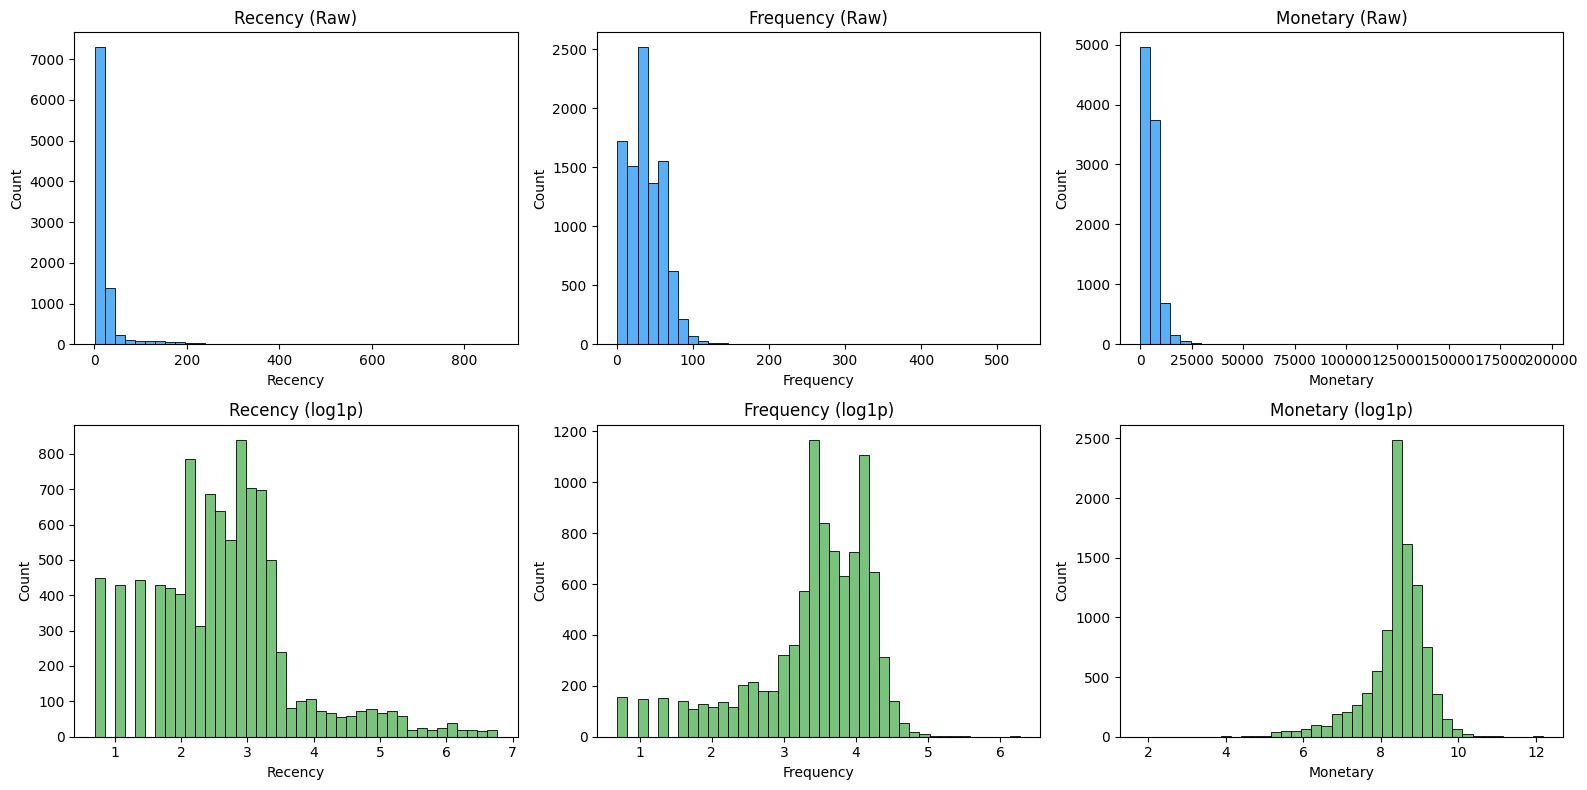

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

rfm_log = np.log1p(rfm_df[['Recency', 'Frequency', 'Monetary']])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm_df[col], bins=40, ax=axes[0, i], color='#2196F3')
    axes[0, i].set_title(f'{col} (Raw)')
    sns.histplot(rfm_log[col], bins=40, ax=axes[1, i], color='#4CAF50')
    axes[1, i].set_title(f'{col} (log1p)')
plt.tight_layout()
plt.show()

## Step 6: Scale the Data & Find Optimal K

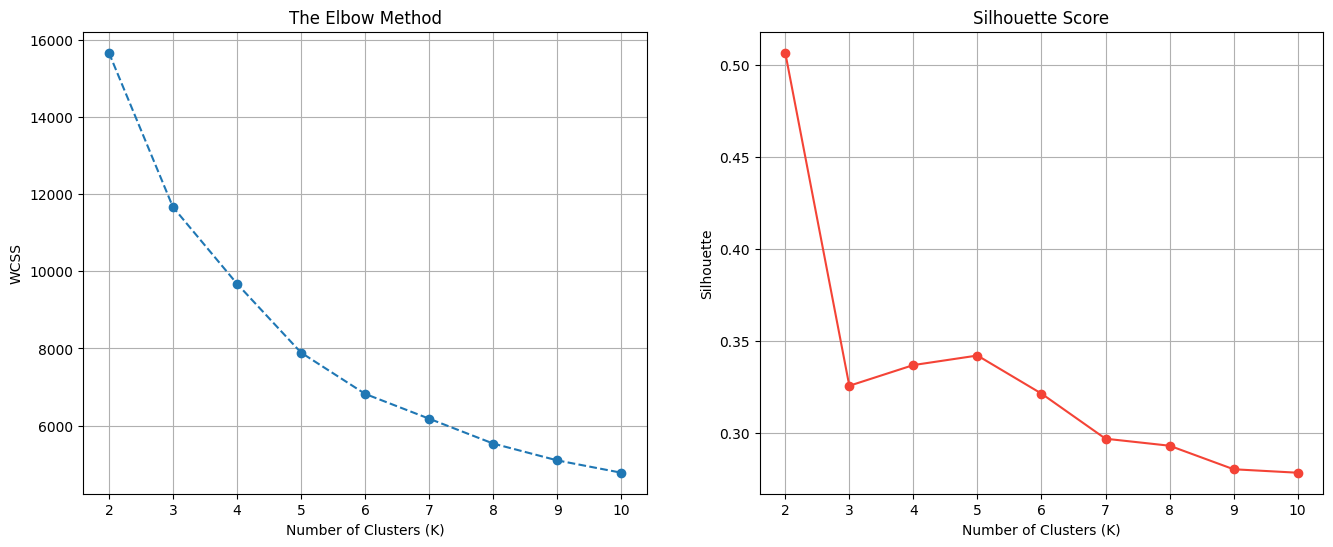

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

wcss, sil = [], []
K_range = range(2, 11)
for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    labels = kmeans.fit_predict(rfm_scaled)
    wcss.append(kmeans.inertia_)
    sil.append(silhouette_score(rfm_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(K_range, wcss, marker='o', linestyle='--')
axes[0].set_title('The Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')
axes[0].grid(True)

axes[1].plot(K_range, sil, marker='o', color='#F44336')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette')
axes[1].grid(True)
plt.show()

## Step 7: Apply K-Means (K=4) & Analyze Segments

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

segment_analysis = rfm_df.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Customers=('Recency', 'size')
).round(1)

print("Analysis of each cluster:")
print(segment_analysis.sort_values(by='Monetary', ascending=False))

Analysis of each cluster:
         Recency  Frequency  Monetary  Customers
Cluster                                         
2            5.6       56.7    8423.2       3322
0           19.4       35.1    5207.5       4390
3          209.4       18.6    2781.9        707
1           25.9        5.7    1354.7       1211


## Step 8: Name the Segments


In [ ]:
remaining = list(segment_analysis.index)

# 1) At Risk: High Recency
at_risk = segment_analysis.loc[remaining, 'Recency'].idxmax(); remaining.remove(at_risk)
# 2) New Customers: Less Frequency
new_cust = segment_analysis.loc[remaining, 'Frequency'].idxmin(); remaining.remove(new_cust)
# 3) Champions: High Monetary
champions = segment_analysis.loc[remaining, 'Monetary'].idxmax(); remaining.remove(champions)
# 4) Others
loyalists = remaining[0]

segment_names = {champions: 'Champions (High Value)',
                 loyalists: 'Potential Loyalists',
                 new_cust: 'New Customers',
                 at_risk: 'At Risk'}
rfm_df['Segment'] = rfm_df['Cluster'].map(segment_names)

segment_summary = rfm_df.groupby('Segment').agg(
    Customers=('Recency', 'size'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(1)
segment_summary['Pct_Customers'] = (segment_summary['Customers'] / segment_summary['Customers'].sum() * 100).round(1)
segment_summary['Pct_Revenue'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(1)
print(segment_summary.sort_values('Avg_Monetary', ascending=False))
print(rfm_df.head())

                        Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                       
Champions (High Value)       3322          5.6           56.7        8423.2   
Potential Loyalists          4390         19.4           35.1        5207.5   
At Risk                       707        209.4           18.6        2781.9   
New Customers                1211         25.9            5.7        1354.7   

                        Total_Revenue  Pct_Customers  Pct_Revenue  
Segment                                                            
Champions (High Value)     27982018.6           34.5         51.4  
Potential Loyalists        22861043.6           45.6         42.0  
At Risk                     1966773.9            7.3          3.6  
New Customers               1640525.0           12.6          3.0  
              Recency  Frequency  Monetary  Cluster                 Segment
CUSTOMER_ID#                             

## Step 9: Visualization

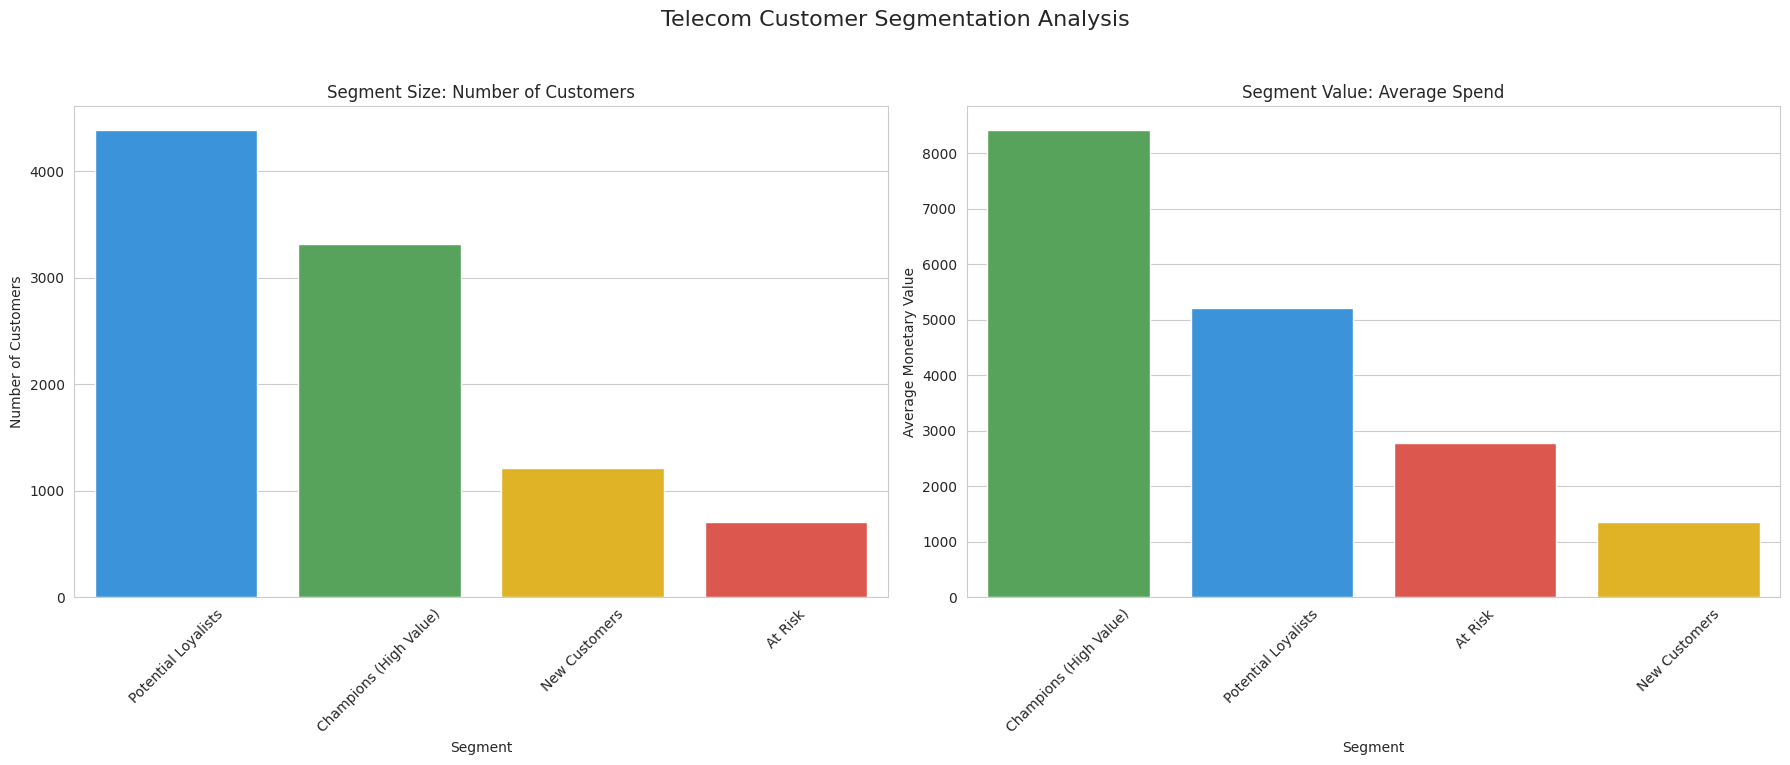

In [ ]:
segment_colors = {
    'Champions (High Value)': '#4CAF50',
    'Potential Loyalists': '#2196F3',
    'New Customers': '#FFC107',
    'At Risk': '#F44336'
}

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Telecom Customer Segmentation Analysis', fontsize=16)

order = rfm_df['Segment'].value_counts().index
sns.countplot(ax=axes[0], data=rfm_df, x='Segment', order=order, hue='Segment', palette=segment_colors, legend=False)
axes[0].set_title('Segment Size: Number of Customers')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)

segment_value = rfm_df.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
sns.barplot(ax=axes[1], x=segment_value.index, y=segment_value.values,
            hue=segment_value.index, palette=segment_colors, legend=False)
axes[1].set_title('Segment Value: Average Spend')
axes[1].set_ylabel('Average Monetary Value')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

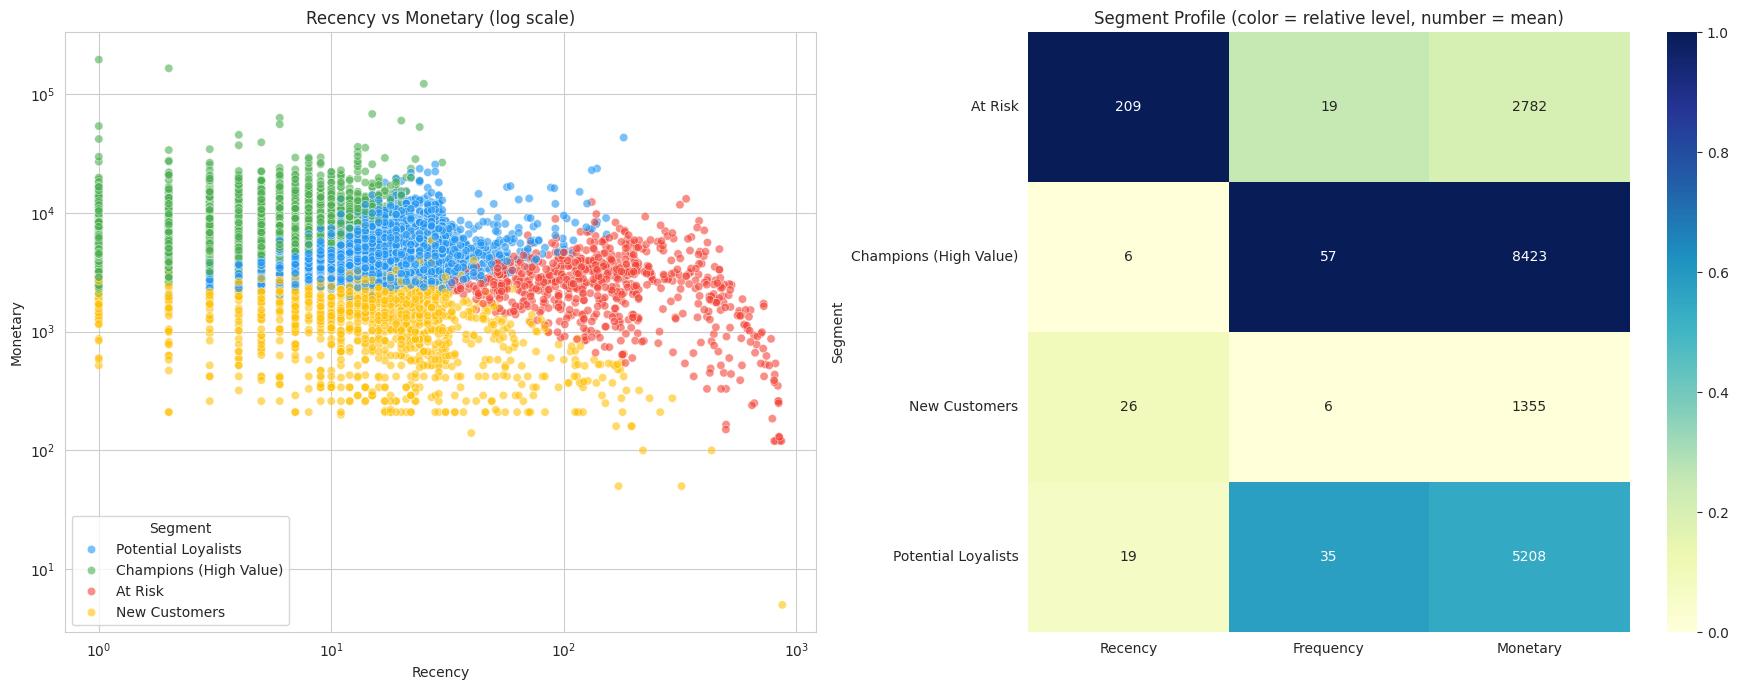

In [ ]:
# Recency vs Monetary scatter + Heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(ax=axes[0], data=rfm_df, x='Recency', y='Monetary', hue='Segment',
                palette=segment_colors, alpha=0.6)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_title('Recency vs Monetary (log scale)')

profile = rfm_df.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
sns.heatmap(profile_norm, annot=profile.round(0), fmt='g', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Segment Profile (color = relative level, number = mean)')
plt.tight_layout()
plt.show()

## Step 10: Enrich with Customer Attributes
نشوف الشرائح دي مرتبطة بحالة الاشتراك (Active/Suspended) وفئة العميل إزاي.

In [ ]:
cust_attr = (customers_unique.groupby('CUSTOMER_ID#')
             .agg(SUBSCRIBER_STATUS=('SUBSCRIBER_STATUS', 'first'),
                  CUSTOMER_CLASS=('CUSTOMER_CLASS', 'first'),
                  SUBSCRIBER_TYPE=('SUBSCRIBER_TYPE', 'first')))
rfm_enriched = rfm_df.join(cust_attr)

print("Segment vs Subscriber Status (% within segment):")
print((pd.crosstab(rfm_enriched['Segment'], rfm_enriched['SUBSCRIBER_STATUS'], normalize='index') * 100).round(1))

print("\nSegment vs Customer Class (% within segment):")
print((pd.crosstab(rfm_enriched['Segment'], rfm_enriched['CUSTOMER_CLASS'], normalize='index') * 100).round(1))

Segment vs Subscriber Status (% within segment):
SUBSCRIBER_STATUS       Active  Suspended
Segment                                  
At Risk                   50.2       49.8
Champions (High Value)    99.9        0.1
New Customers             92.9        7.1
Potential Loyalists       98.6        1.4

Segment vs Customer Class (% within segment):
CUSTOMER_CLASS             A   A+     B    B+     C    C+    D
Segment                                                       
At Risk                 20.1  4.1  21.4  18.2   8.8  26.7  0.7
Champions (High Value)  20.3  1.7  17.9  54.2   1.3   4.8  0.0
New Customers            5.2  0.7   5.3  17.5  22.5  48.0  0.7
Potential Loyalists      8.4  1.0  31.8  39.2   3.9  15.7  0.0


## Step 11: Export Results

In [ ]:
rfm_enriched.reset_index().rename(columns={'CUSTOMER_ID#': 'CUSTOMER_ID'}).to_csv('telecom_rfm_segments.csv', index=False)
print("Saved: telecom_rfm_segments.csv")

Saved: telecom_rfm_segments.csv


Notes for Interpretation

Frequency in telecom is tied to tenure: Because billing is monthly, older customers naturally have a high frequency. Here, the "Champions" are likely just long-term, high-paying customers, not necessarily those who "purchased frequently."

At Risk = Potential Churn: A high Recency score means the customer hasn't paid for a long time relative to the monthly billing cycle.

Customers with no payments are excluded from the RFM analysis and must be handled as a separate segment.

The last month of the data is incomplete (the data cuts off on May 20, 2025), which is normal and accounted for in the snapshot date.

---
# Part 2: AI/ML Use Case — Predicting Payment Lapse (Churn Risk)

## 1. The use case
**Early-warning model for subscriber churn.** Every month, score every active subscriber with the probability that they will **stop paying within the next 60 days**, so the retention team can contact the highest-risk (and highest-value) subscribers *before* they leave.

RFM from Part 1 describes **what already happened**. This model looks **forward**, and it re-uses the RFM idea (recency, frequency, monetary) as input signals.

## 2. Prediction target
| | |
|---|---|
| **Unit of prediction** | one subscriber at one snapshot date `T` (the 1st of each month) |
| **Population** | subscribers still *active* at `T` (paid at least once in the 60 days before `T`) |
| **Target `y`** | `1` if the subscriber makes **no payment in the 60 days after `T`**, otherwise `0` |
| **Type** | binary classification (probability output) |

**Why 60 days?** The gap between two consecutive payments has a median of 17 days and a 99th percentile of about 61 days, so 60 days with no payment is clearly abnormal and not just a late bill.

**Why not use `SUBSCRIBER_STATUS = Suspended` as the target?** It is a single *current* snapshot with no history, so we could not build "as-of" training examples from it (see the leakage section).

## 3. Candidate features (8)
All features are computed **only from data before `T`**.

| # | Feature | Meaning | Why it should help |
|---|---|---|---|
| 1 | `days_since_last` | Days since the last payment (Recency) | Strongest early sign of a lapse |
| 2 | `n_pay_90d` | Number of payments in the last 90 days (Frequency) | Falling activity before churn |
| 3 | `rev_90d` | Revenue in the last 90 days (Monetary) | Value and size of the customer |
| 4 | `rev_trend` | Revenue last 90d ÷ revenue previous 90d (missing for brand-new subscribers) | Downgrading before leaving |
| 5 | `addon_share` | Add-on revenue ÷ rent revenue (last 90d) | Engagement with extras |
| 6 | `avg_gap_days` | Average days between the last 6 payments | The subscriber's normal payment rhythm; a gap well beyond it means a missed cycle |
| 7 | `tenure_months` | Months since `ACTIVATION_DATE` | Newer customers churn more |
| 8 | `class_ord` | `CUSTOMER_CLASS` encoded D → A+ | Customer tier |

## 4. Train / test split: by time, not randomly
A random split would put the same subscriber's March snapshot in train and their April snapshot in test, so the model would "see the future". We split on the calendar instead, which mirrors real use (train on the past, score the future):

- **Train:** snapshots from 2023-07 to 2024-06
- **Embargo:** 60 days skipped, because a train label at `T` looks 60 days ahead and must not overlap the test period
- **Test:** snapshots from 2024-08 to 2025-03 (the last snapshot whose 60-day outcome is fully observed, since the data ends on 2025-05-20)

## 5. Evaluation metrics
Only about 2–3% of subscribers lapse, so **accuracy is useless** (predicting "nobody lapses" is 97% accurate).

1. **PR-AUC (Average Precision):** quality of the ranking on a rare class. The random baseline equals the lapse rate, so it is easy to judge the lift.
2. **Recall @ Top 10%:** if the retention team can only call the 10% highest-risk subscribers, what share of the real lapsers do they reach? This ties the model directly to team capacity.

(Precision @ Top 10% is reported alongside, because it tells the team how many calls are "wasted".)

## 6. Preventing data leakage (the one safeguard)
**Point-in-time feature construction + the time split above:** every feature for snapshot `T` is built from rows with `CONNECT_DATE < T`, and the label only from the 60 days after `T`.

The concrete trap in *this* dataset: `SUBSCRIBER_STATUS` and `STATUS_DATE` in `Customer.csv` are a **current snapshot taken after the outcome**. A suspended subscriber is, by definition, one who stopped paying, so using them as features would give a model that looks perfect in testing and is useless in production. They are excluded from the features and used only in Part 1 for profiling.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.inspection import permutation_importance

HORIZON = 60   # days with no payment = lapse

pay = payments_df.sort_values(['SUBSCRIBER_ID', 'CONNECT_DATE']).copy()
# Gap to the PREVIOUS payment: depends only on the past, so it is safe to precompute
pay['gap_prev'] = pay.groupby('SUBSCRIBER_ID')['CONNECT_DATE'].diff().dt.days

sub_attr = customers_unique.set_index('SUBSCRIBER_ID#').copy()
sub_attr['ACT'] = pd.to_datetime(sub_attr['ACTIVATION_DATE'], errors='coerce')
class_map = {'D': 0, 'C': 1, 'C+': 2, 'B': 3, 'B+': 4, 'A': 5, 'A+': 6}

FEATURES = ['days_since_last', 'n_pay_90d', 'rev_90d', 'rev_trend',
            'addon_share', 'avg_gap_days', 'tenure_months', 'class_ord']


def build_snapshot(T, with_label=True):
    """Features use ONLY payments before T. Label uses ONLY the HORIZON days after T."""
    hist = pay[pay['CONNECT_DATE'] < T]
    d90  = hist[hist['CONNECT_DATE'] >= T - pd.Timedelta(days=90)]
    prev = hist[(hist['CONNECT_DATE'] >= T - pd.Timedelta(days=180)) &
                (hist['CONNECT_DATE'] <  T - pd.Timedelta(days=90))]

    g = hist.groupby('SUBSCRIBER_ID')
    f = pd.DataFrame({'days_since_last': (T - g['CONNECT_DATE'].max()).dt.days})
    f['avg_gap_days'] = hist.groupby('SUBSCRIBER_ID').tail(6).groupby('SUBSCRIBER_ID')['gap_prev'].mean()
    f['n_pay_90d']    = d90.groupby('SUBSCRIBER_ID').size()
    f['rev_90d']      = d90.groupby('SUBSCRIBER_ID')['Total_Revenue'].sum()
    f['rev_prev_90d'] = prev.groupby('SUBSCRIBER_ID')['Total_Revenue'].sum()
    f['addon_90d']    = d90.groupby('SUBSCRIBER_ID')['ADDON_REVENUE'].sum()
    f['rent_90d']     = d90.groupby('SUBSCRIBER_ID')['RENT_REVENUE'].sum()
    f = f.fillna({'n_pay_90d': 0, 'rev_90d': 0, 'rev_prev_90d': 0, 'addon_90d': 0, 'rent_90d': 0})

    f = f[f['days_since_last'] <= HORIZON]                   # active at T only
    f['rev_trend']      = np.where(f['rev_prev_90d'] > 0, f['rev_90d'] / f['rev_prev_90d'], np.nan)   # NaN = no previous period
    f['addon_share']    = f['addon_90d'] / (f['rent_90d'] + 1)
    f = f.join(sub_attr[['ACT', 'CUSTOMER_CLASS']])
    f['tenure_months']  = ((T - f['ACT']).dt.days / 30.4).clip(lower=0)
    f['class_ord']      = f['CUSTOMER_CLASS'].map(class_map)
    f['SNAP'] = T

    if with_label:
        fut = pay[(pay['CONNECT_DATE'] >= T) & (pay['CONNECT_DATE'] < T + pd.Timedelta(days=HORIZON))]
        f['y'] = (~f.index.isin(fut['SUBSCRIBER_ID'].unique())).astype(int)
    return f.reset_index().rename(columns={'index': 'SUBSCRIBER_ID'})


# Only snapshots whose full 60-day outcome window is observed (data ends 2025-05-20)
snapshots = pd.date_range('2023-07-01', pay['CONNECT_DATE'].max() - pd.Timedelta(days=HORIZON), freq='MS')
D = pd.concat([build_snapshot(T) for T in snapshots], ignore_index=True)

print("Snapshots:", len(snapshots), "| rows:", len(D), "| overall lapse rate:", round(D['y'].mean(), 4))
print(D[['SUBSCRIBER_ID', 'SNAP'] + FEATURES + ['y']].head())

Snapshots: 21 | rows: 164976 | overall lapse rate: 0.0243
   SUBSCRIBER_ID       SNAP  days_since_last  n_pay_90d  rev_90d  rev_trend  \
0       49957772 2023-07-01                6        3.0    360.0   1.000000   
1       49966840 2023-07-01               26        3.0    510.0   1.000000   
2       49967928 2023-07-01               25        5.0    480.0   1.333333   
3       49984751 2023-07-01               23        3.0    360.0   1.000000   
4       49989189 2023-07-01               11        4.0    390.0   1.500000   

   addon_share  avg_gap_days  tenure_months  class_ord  y  
0     0.000000          30.2      51.381579          4  0  
1     0.000000          30.4      51.250000          5  0  
2     0.249480          15.5      51.250000          3  0  
3     0.000000          31.2      51.184211          4  0  
4     0.076726          28.6      51.184211          4  0  


In [ ]:
# --- Time-based split with a 60-day embargo ---
train_end  = pd.Timestamp('2024-06-01')
test_start = train_end + pd.Timedelta(days=HORIZON)       # first snapshot on/after 2024-07-31 -> 2024-08-01

train = D[D['SNAP'] <= train_end]
test  = D[D['SNAP'] >= test_start].copy()
print(f"Train: {len(train):,} rows, lapse rate {train['y'].mean():.3%}  ({train['SNAP'].min().date()} -> {train['SNAP'].max().date()})")
print(f"Test : {len(test):,} rows, lapse rate {test['y'].mean():.3%}  ({test['SNAP'].min().date()} -> {test['SNAP'].max().date()})")

model = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=300, random_state=42)
model.fit(train[FEATURES], train['y'])
test['score'] = model.predict_proba(test[FEATURES])[:, 1]

def recall_precision_at_k(y, s, k=0.10):
    n = int(len(y) * k)
    top = np.argsort(-np.asarray(s))[:n]
    hit = np.asarray(y)[top]
    return hit.sum() / np.sum(y), hit.mean()

# Naive baseline: "the longer since the last payment, the riskier"
rows = []
for name, s in [('Baseline: days_since_last only', test['days_since_last']),
                ('Gradient Boosting (8 features)', test['score'])]:
    rec, prec = recall_precision_at_k(test['y'], s)
    rows.append({'Model': name,
                 'PR-AUC': average_precision_score(test['y'], s),
                 'Recall@Top10%': rec,
                 'Precision@Top10%': prec,
                 'ROC-AUC': roc_auc_score(test['y'], s)})
results = pd.DataFrame(rows).set_index('Model').round(3)
print(f"\nRandom-guess PR-AUC = lapse rate = {test['y'].mean():.3f}")
print(results)

Train: 89,525 rows, lapse rate 1.937%  (2023-07-01 -> 2024-06-01)
Test : 67,444 rows, lapse rate 3.025%  (2024-08-01 -> 2025-03-01)

Random-guess PR-AUC = lapse rate = 0.030
                                PR-AUC  Recall@Top10%  Precision@Top10%  \
Model                                                                     
Baseline: days_since_last only   0.149          0.434             0.131   
Gradient Boosting (8 features)   0.260          0.635             0.192   

                                ROC-AUC  
Model                                    
Baseline: days_since_last only    0.716  
Gradient Boosting (8 features)    0.874  


        rows  lapse_rate  lift_vs_avg
decile                               
10      6745       0.192         6.35
9       6744       0.045         1.48
8       6744       0.021         0.69
7       6745       0.014         0.46
6       6744       0.010         0.34
5       6744       0.007         0.22
4       6745       0.007         0.22
3       6744       0.003         0.10
2       6744       0.003         0.11
1       6745       0.001         0.03


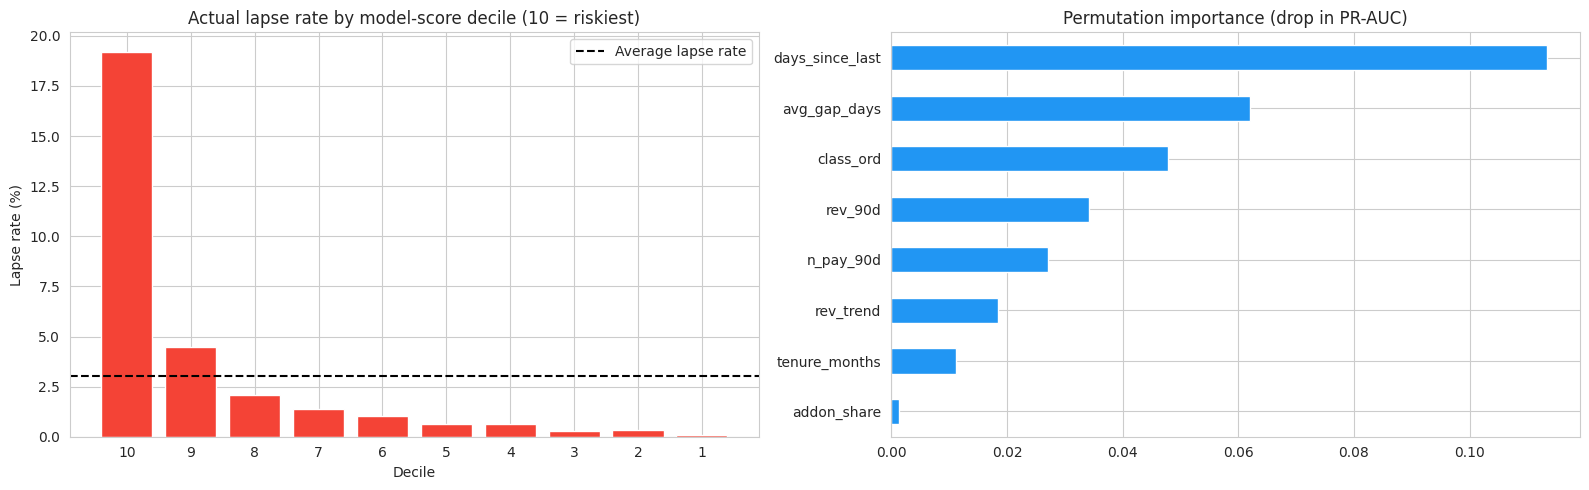

In [ ]:
# --- Lift by decile + feature importance ---
test['decile'] = pd.qcut(test['score'].rank(method='first'), 10, labels=False) + 1   # 10 = riskiest
lift = (test.groupby('decile')
            .agg(rows=('y', 'size'), lapse_rate=('y', 'mean'))
            .sort_index(ascending=False))
lift['lift_vs_avg'] = (lift['lapse_rate'] / test['y'].mean()).round(2)
print(lift.round(3))

sample = test.sample(20000, random_state=42)
imp = permutation_importance(model, sample[FEATURES], sample['y'],
                             scoring='average_precision', n_repeats=3, random_state=42)
imp_s = pd.Series(imp.importances_mean, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(lift.index.astype(str), lift['lapse_rate'] * 100, color='#F44336')
axes[0].axhline(test['y'].mean() * 100, color='k', linestyle='--', label='Average lapse rate')
axes[0].set_title('Actual lapse rate by model-score decile (10 = riskiest)')
axes[0].set_xlabel('Decile'); axes[0].set_ylabel('Lapse rate (%)'); axes[0].legend()
imp_s.plot(kind='barh', ax=axes[1], color='#2196F3')
axes[1].set_title('Permutation importance (drop in PR-AUC)')
plt.tight_layout(); plt.show()

### How to read the results
- **The model beats both references.** PR-AUC is **0.26** against 0.03 for random guessing and 0.15 for the simple "days since last payment" rule. Calling the top 10% reaches about **63%** of the subscribers who really lapse, versus 43% for the simple rule.
- **Strong concentration of risk:** the riskiest decile lapses at about **19%**, roughly **6x** the average, while the bottom half is below 1%.
- **Precision is still low in absolute terms.** In the top 10%, about **4 out of 5 flagged subscribers would not have lapsed** (lapse is a rare event). This is exactly why the score should prioritise human attention rather than trigger automatic action (section 9).
- The test lapse rate (about 3.0%) is higher than the train rate (about 1.9%): a first sign of drift that we examine below.

## 7. Using the prediction in Power BI
**Step 1: Score monthly.** Re-run the pipeline on the 1st of each month and **append** the output (do not overwrite) to a table such as `fact_churn_scores`. Keeping the history lets us later compare predictions with what really happened.

**Step 2: Data model.** `fact_churn_scores` → `dim_subscriber/customer` (class, type) → `dim_date`, plus the RFM segment from Part 1 as a column.

**Step 3: Report pages**
| Page | Content |
|---|---|
| **Overview** | KPI cards: active subscribers, # High-risk, **Expected Monthly Revenue at Risk**; trend by month |
| **Risk × RFM segment** | Matrix of Segment × Risk band. The key action group is *Champions with High risk* (high value + high risk) |
| **Retention worklist** | Table sorted by expected revenue at risk, with the drivers (`days_since_last`, `rev_trend`), filters by class / band, and a column for the agent's outcome |
| **Model health** | PR-AUC / Recall@10% per month, mean predicted vs actual lapse rate, PSI per feature (next section) |

**Key DAX measure**
```DAX
Expected Revenue at Risk =
SUMX ( fact_churn_scores, fact_churn_scores[risk_score] * fact_churn_scores[avg_monthly_revenue] )
```

**Risk bands** are set by *capacity*, not by a magic probability: High = top 10% (what the team can call), Medium = next 20%, Low = the rest. If the team grows, change the percentage, not the model.

In [ ]:
# --- Score the latest snapshot and export for Power BI ---
# Refit on ALL labeled snapshots (train + test) for the production model
final_model = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05, max_iter=300, random_state=42)
final_model.fit(D[FEATURES], D['y'])

score_df = build_snapshot(snapshot_date, with_label=False)       # snapshot_date = day after last payment (Part 1)
score_df['risk_score']    = final_model.predict_proba(score_df[FEATURES])[:, 1]
score_df['risk_pct_rank'] = score_df['risk_score'].rank(pct=True)
score_df['risk_band']     = pd.cut(score_df['risk_pct_rank'], [0, 0.70, 0.90, 1.0],
                                   labels=['Low', 'Medium', 'High'], include_lowest=True)

score_df['CUSTOMER_ID']  = score_df['SUBSCRIBER_ID'].map(customers_unique.set_index('SUBSCRIBER_ID#')['CUSTOMER_ID#'])
score_df['RFM_Segment']  = score_df['CUSTOMER_ID'].map(rfm_df['Segment'])
# Recurring revenue only (RENT): one-off device / creation fees would inflate 'revenue at risk'
score_df['avg_monthly_revenue'] = (score_df['rent_90d'] / 3).round(2)
score_df['expected_revenue_at_risk'] = (score_df['risk_score'] * score_df['avg_monthly_revenue']).round(2)
score_df['model_version'] = 'hgb_v1'
score_df['scored_at'] = snapshot_date

export_cols = ['SUBSCRIBER_ID', 'CUSTOMER_ID', 'scored_at', 'risk_score', 'risk_band', 'RFM_Segment',
               'avg_monthly_revenue', 'expected_revenue_at_risk',
               'days_since_last', 'n_pay_90d', 'rev_trend', 'CUSTOMER_CLASS', 'model_version']
score_df[export_cols].to_csv('churn_risk_scores.csv', index=False)

print("Scored subscribers:", len(score_df))
print("\nRisk band x RFM segment (count):")
print(pd.crosstab(score_df['RFM_Segment'], score_df['risk_band']))
print("\nTop 10 retention worklist (by expected revenue at risk):")
print(score_df.sort_values('expected_revenue_at_risk', ascending=False)[export_cols].head(10))

Scored subscribers: 8875

Risk band x RFM segment (count):
risk_band                Low  Medium  High
RFM_Segment                               
At Risk                    0       2    93
Champions (High Value)  3098     183    42
New Customers            178     590   355
Potential Loyalists     2936    1000   398

Top 10 retention worklist (by expected revenue at risk):
      SUBSCRIBER_ID       CUSTOMER_ID  scored_at  risk_score risk_band  \
7616     2204983199        1104940191 2025-05-21    0.764705      High   
8377     2206943215  1017911005300389 2025-05-21    0.960487      High   
7265     2203910942        1103867599 2025-05-21    0.201055      High   
3791       81710580  1017911002323996 2025-05-21    0.570008      High   
5131      120168820       11023281162 2025-05-21    0.453511      High   
604        55642965        1102884746 2025-05-21    0.093536      High   
4712       94071284  1017911002358867 2025-05-21    0.263789      High   
5851      130040467       1104222

## 8. Monitoring model and data drift
Two different things can go wrong: the **inputs change** (data drift) or the **relationship between inputs and churn changes** (concept drift). We watch both.

| What | How | Frequency | Action trigger |
|---|---|---|---|
| **Data drift** | **PSI** (Population Stability Index) of each feature and of the score vs the training period | Monthly | PSI 0.10–0.25 = watch, **> 0.25 = investigate / retrain** |
| **Data quality** | Nulls, new `CUSTOMER_CLASS` values, payment volume per month, late-loading files (e.g. the last month is always partial) | Every load | Any break stops scoring |
| **Calibration drift** | Mean predicted risk vs actual lapse rate per month | Monthly, once the 60-day outcome is known | Gap > ~30% relative |
| **Performance drift** | PR-AUC and Recall@Top10% on each matured month vs the test baseline | Monthly (with a 60-day lag) | Drop beyond agreed tolerance |
| **Business drift** | Share of High-risk subscribers, churn rate by segment, pricing/plan changes | Monthly | Review with the business owner |

Because labels arrive **60 days late**, input drift (PSI) is our *early* warning, and performance metrics are the *confirmation*. All of these feed the **Model health** page in Power BI.

                   PSI       Status
rev_90d          0.633  Investigate
addon_share      0.157        Watch
tenure_months    0.048       Stable
rev_trend        0.012       Stable
class_ord        0.009       Stable
n_pay_90d        0.003       Stable
avg_gap_days     0.002       Stable
days_since_last  0.001       Stable

Calibration by month:
            predicted  actual
SNAP                         
2024-08-01     0.0200  0.0240
2024-09-01     0.0197  0.0250
2024-10-01     0.0207  0.0254
2024-11-01     0.0203  0.0263
2024-12-01     0.0201  0.0309
2025-01-01     0.0209  0.0358
2025-02-01     0.0204  0.0387
2025-03-01     0.0204  0.0349

Average RENT per payment by quarter:
CONNECT_DATE
2023Q1    108.6
2023Q2    110.2
2023Q3    111.4
2023Q4    113.6
2024Q1    148.9
2024Q2    151.2
2024Q3    153.6
2024Q4    168.3
2025Q1    202.4
2025Q2    202.1
Freq: Q-DEC


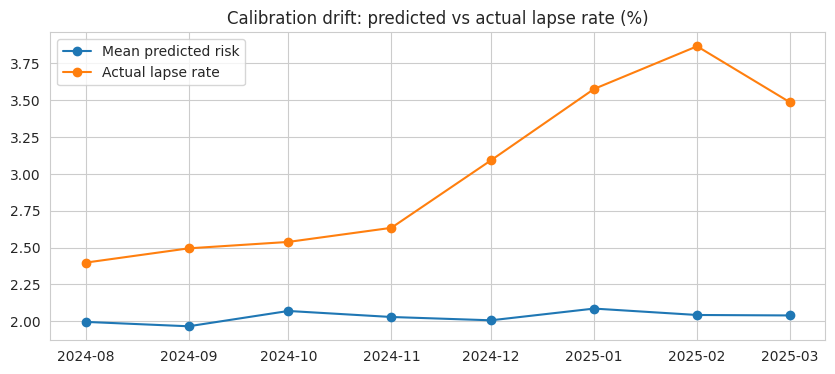

In [ ]:
# --- Drift demo: PSI (train period vs test period) + calibration by month ---
def psi(expected, actual, bins=10):
    expected, actual = expected.dropna(), actual.dropna()
    cuts = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    cuts[0], cuts[-1] = -np.inf, np.inf
    e = np.histogram(expected, cuts)[0] / len(expected)
    a = np.histogram(actual, cuts)[0] / len(actual)
    e, a = np.clip(e, 1e-4, None), np.clip(a, 1e-4, None)
    return float(np.sum((a - e) * np.log(a / e)))

psi_table = pd.DataFrame({'PSI': {f: psi(train[f], test[f]) for f in FEATURES}}).round(3)
psi_table['Status'] = pd.cut(psi_table['PSI'], [-1, 0.10, 0.25, np.inf], labels=['Stable', 'Watch', 'Investigate'])
print(psi_table.sort_values('PSI', ascending=False))

# Calibration in the test period: predicted vs actual lapse rate per snapshot
calib = test.groupby('SNAP').agg(predicted=('score', 'mean'), actual=('y', 'mean'))
print("\nCalibration by month:"); print(calib.round(4))

# Why does rev_90d drift? Average rent per payment over time
rent_trend = pay.groupby(pay['CONNECT_DATE'].dt.to_period('Q'))['RENT_REVENUE'].mean().round(1)
print("\nAverage RENT per payment by quarter:"); print(rent_trend.to_string())
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(calib.index, calib['predicted'] * 100, marker='o', label='Mean predicted risk')
ax.plot(calib.index, calib['actual'] * 100, marker='o', label='Actual lapse rate')
ax.set_title('Calibration drift: predicted vs actual lapse rate (%)')
ax.legend(); ax.grid(True); plt.show()

**What the drift check tells us (on this data):**
1. **Pricing drift.** `rev_90d` is flagged *Investigate* (PSI above 0.25). The cause is visible in the table above: the average rent per payment almost doubled from about 109 (2023) to about 202 (2025), so nominal revenue in the test period is simply on a different scale. Revenue features should be monitored closely, and relative features such as `rev_trend` (which stays stable) are safer than raw amounts. A rolling training window also helps.
2. **Concept drift.** The actual lapse rate climbs from about 2.4% to 3.5-3.9% while the model's average prediction stays near 2.0%. The model still *ranks* well (Recall@Top10% above), but its raw probabilities become too optimistic. In production this would trigger a **recalibration or retrain**, which is why monitoring is part of the design and not an optional extra.
3. A feature that grows with calendar time (for example "months since first payment", which we deliberately avoided because the data only starts in 2023) would show high PSI by construction, so feature design matters as much as monitoring.

## 9. Why a prediction should support, not replace, a business decision
1. **It is a probability, not a fact.** Even in the riskiest decile most subscribers do **not** lapse. Acting automatically would mean treating many loyal customers as defectors.
2. **It predicts *who* may leave, not *why*, and not *what will work*.** A missed payment can come from salary timing, travel, a billing-system issue or a network outage. Only a person with context can choose between a call, an offer or doing nothing. The model also cannot tell whether an incentive would change the outcome, so the effect of any campaign should be measured with a **holdout/control group**.
3. **Wrong actions have real costs.** Unneeded discounts erode revenue and teach customers to wait for offers. Automatic suspension or penalties based on a score would harm customers and the brand. The recommended action here is *outreach*, never an automatic restriction.
4. **The model can be wrong in ways it cannot see.** Data drift, a partial last month, a pricing change or a new competitor can break its assumptions silently (section 8). People notice what the data does not contain.
5. **Fairness and accountability.** A named person must own the decision and be able to explain it to the customer. Class or demographic patterns in the scores should be reviewed so that service quality is not unintentionally lower for some groups.

**Operating model:** the model *narrows* 9,000+ subscribers to a short, ranked worklist → a retention agent *reviews* it using context the model lacks → the agent *decides and records* the action and outcome → that outcome *feeds back* as new labels and as evidence of whether the intervention worked.

In [ ]:
# --- Export model-health tables for Power BI ---
lift_out = lift.reset_index().rename(columns={'decile': 'Decile', 'rows': 'Rows',
                                              'lapse_rate': 'Lapse_Rate', 'lift_vs_avg': 'Lift'})
lift_out['Lapse_Rate_Pct'] = (lift_out['Lapse_Rate'] * 100).round(2)
lift_out.to_csv('model_lift.csv', index=False)

calib_out = calib.reset_index().rename(columns={'SNAP': 'Snapshot', 'predicted': 'Predicted', 'actual': 'Actual'})
calib_out['Predicted_Pct'] = (calib_out['Predicted'] * 100).round(2)
calib_out['Actual_Pct'] = (calib_out['Actual'] * 100).round(2)
calib_out.to_csv('model_calibration.csv', index=False)

metrics_out = results.reset_index().rename(columns={'PR-AUC': 'PR_AUC', 'Recall@Top10%': 'Recall_Top10',
                                                    'Precision@Top10%': 'Precision_Top10', 'ROC-AUC': 'ROC_AUC'})
metrics_out.to_csv('model_metrics.csv', index=False)

from google.colab import files
for f in ['telecom_rfm_segments.csv', 'churn_risk_scores.csv', 'model_lift.csv', 'model_calibration.csv', 'model_metrics.csv']:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>